# FRAUD DETECTION MODEL

## Problem Statement

Millions of transactions of all kinds, including CASH-IN, CASH-OUT, DEBIT, PAYMENT, and TRANSFER, take place every day on mobile money platforms, raising concerns about financial fraud. Finding fraudulent activity in the more than 6.3 million transaction records is a significant challenge because it has been demonstrated that current fraud detection algorithms mistakenly identify legal transactions as fraudulent. While false positives interfere with legal transactions and undermine consumer trust, undiscovered fraud can result in substantial financial losses for both customers and service providers.

### Objectives
The main objective of this project is to build a machine learning model that accurately detects fraudulent transactions while minimizing false alarms. This will be achieved through exploratory data analysis to understand transaction patterns, feature engineering to strengthen predictive signals, and the development and comparison of multiple classification models including Logistic Regression, Random Forest, and XGBoost. The final model will be deployed as an interactive web application to allow real-time fraud prediction on new transactions.

## Data Collection

In [1]:
import pandas as pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [3]:
df = pandas.read_csv("AIML Dataset.csv")

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Data Preprocessing

In [5]:
df.info

<bound method DataFrame.info of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1

In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
df.shape

(6362620, 11)

In [11]:
df["isFraud"].value_counts()[1]

8213

In [12]:
(df["isFraud"].value_counts()[1] / df.shape[0]) * 100

0.12908204481801522

In [13]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)

0.13

## Exploratory Data Analysis (EDA)

### Transaction types

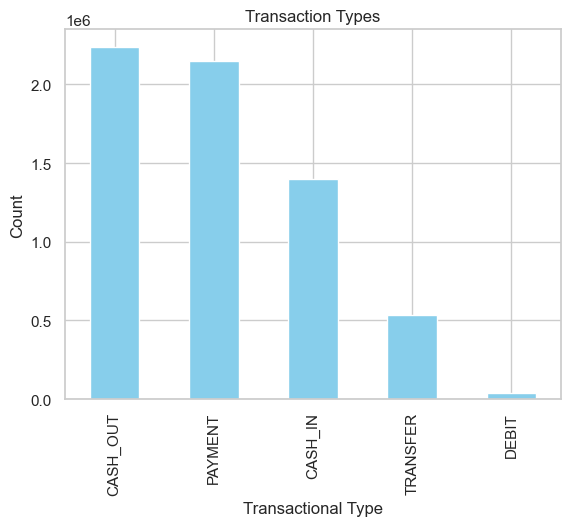

In [14]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types", color = "skyblue")
plt.xlabel("Transactional Type")
plt.ylabel("Count")
plt.show()

The bar chart shows the distribution of transaction types in the dataset, with the y-axis in millions (1e6). CASH_OUT is the most frequent transaction type at approximately 2.2 million transactions, closely followed by PAYMENT at around 2.15 million. CASH_IN comes third at roughly 1.4 million, while TRANSFER has about 530,000 transactions. DEBIT is the least common, barely visible on the chart. This distribution provides a first summary of the data and poses a crucial question: even though CASH_OUT and PAYMENT are the most common transaction types, it is unclear which types are most linked to fraud; this will be investigated in the study that follows.

### Fraud Rates By Type

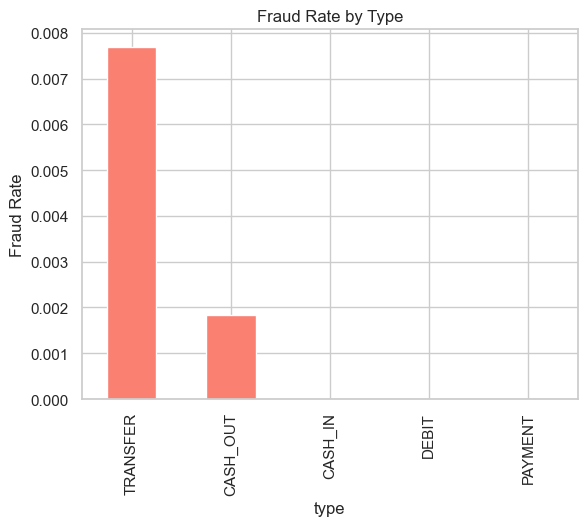

In [15]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

The bar chart shows the fraud rate by transaction type. TRANSFER has the highest fraud rate at approximately 0.77%, followed by CASH_OUT at around 0.19%. The remaining transaction types (CASH_IN, DEBIT, and PAYMENT) show a fraud rate of essentially zero, meaning fraud exclusively occurs in TRANSFER and CASH_OUT transactions. This confirms that transaction type is a strong indicator of fraud.

In [16]:
fraud_by_type

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

### Amount Statistics

In [17]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int32

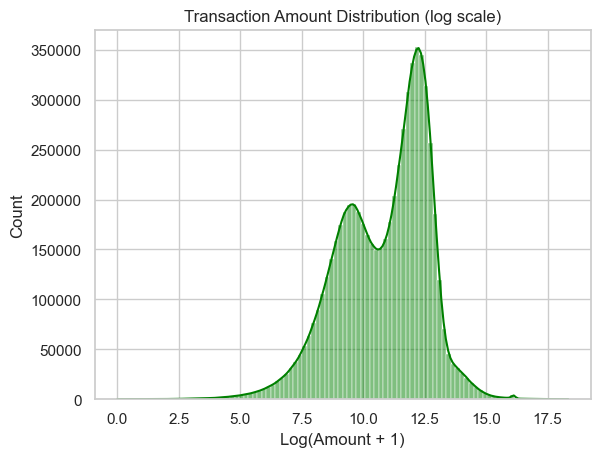

In [18]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color = "green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.show()

The histogram displays the distribution of transaction amounts on a log scale.
The distribution is bimodal, with two peaks around log values 10 and 12,
suggesting two common clusters of transaction sizes. The distribution is right-skewed, with very few extremely large transactions trailing off toward log value 17-18. The two peaks may correspond to the TRANSFER and CASH_OUT transaction types identified earlier as the only fraud-associated types.

### Relationship of the Fraud and Amount

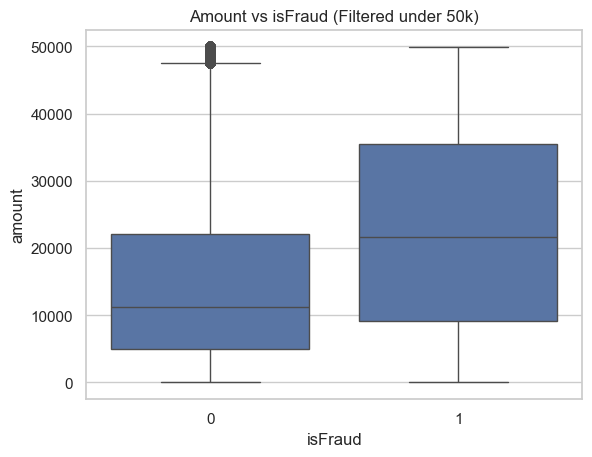

In [19]:
sns.boxplot(data=df[df["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

The boxplot, which is filtered under 50k to make it easier to read, compares transaction quantities between fraudulent (1) and non-fraudulent (0) transactions. Fraudulent transactions tend to have a higher median amount (around 22,000) compared to non-fraudulent ones (around 10,000), suggesting fraudsters tend to target larger transactions. Fraudulent transactions also show a wider spread, meaning the amounts are more variable. This indicates that amount could be a useful feature for fraud detection.

### The Balance Chains and the Anomalies

In [20]:
# Creating two different columns as bal difference of the origin of account and
# destination account
# To see whether there are aby negative balances on that side

df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [21]:
df["balanceDiffOrig"] < 0

0          False
1          False
2          False
3          False
4          False
           ...  
6362615    False
6362616    False
6362617    False
6362618    False
6362619    False
Name: balanceDiffOrig, Length: 6362620, dtype: bool

In [22]:
(df["balanceDiffOrig"] < 0).sum()

1399253

In [23]:
(df["balanceDiffDest"] < 0).sum()

1238864

In [24]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


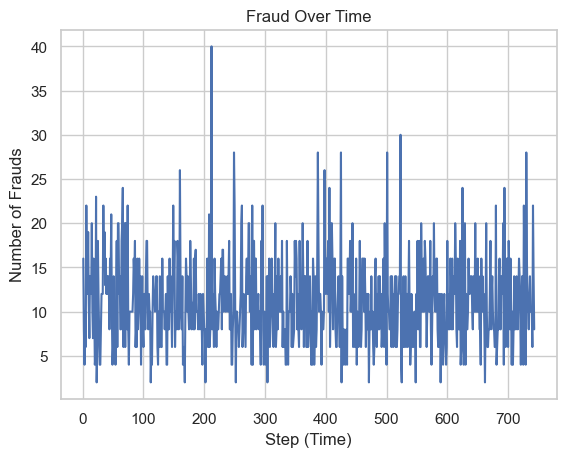

In [25]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label="Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Fraud Over Time")
plt.grid(True)
plt.show()



The plot shows the number of fraudulent transactions at each time step. The fraud count fluctuates randomly between roughly 5 and 30 throughout the entire period, with no clear upward or downward trend and no seasonal pattern the notable spike to 40 around step 200 appears to be an outlier rather than a meaningful trend. This suggests fraud occurrence is not time-dependent, meaning the step feature is unlikely to add predictive value and can be dropped from the model.

In [26]:
df.drop(columns="step", inplace=True)

In [27]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


### Customer Transactions

#### Top Senders and Top Receivers

In [28]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [29]:
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [30]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

### Transfer and Cash Out

In [31]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [32]:
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [33]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

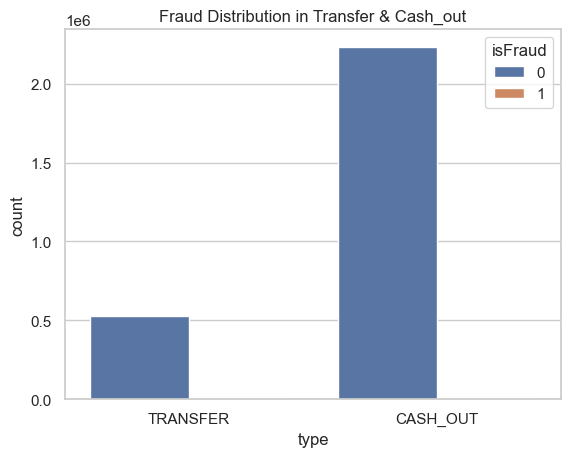

In [34]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash_out")
plt.show()

The chart shows that CASH_OUT transactions significantly outnumber TRANSFER transactions, with over 2 million vs roughly 500,000 records. In both transaction types, fraudulent cases (isFraud = 1) are barely visible due to being extremely rare compared to legitimate transactions, reinforcing the severe class imbalance in the dataset, which is an important consideration when building a fraud detection model.


### Correlation Matrix

In [35]:
# filtering the numeric columns
corr = df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


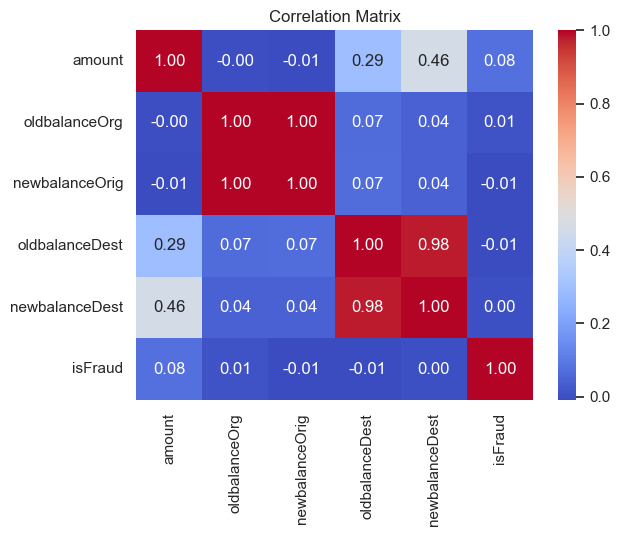

In [36]:
sns.heatmap(corr,annot=True,cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that most features have weak linear correlations with each other. The strongest correlation (0.98) is between oldbalanceDest and newbalanceDest, which is expected since the destination balance before and after a transaction are naturally linked. Similarly, oldbalanceOrg and newbalanceOrig show a near-perfect correlation of 1.00 for the same reason. The amount and newbalanceDest share a moderate correlation of 0.46, as larger transactions tend to increase the destination balance more. Notably, isFraud shows near-zero correlation with all other features, suggesting that fraud cannot be detected through simple linear relationships and will likely require more sophisticated modeling techniques.

In [37]:
# filtering the customers
zero_after_transfer = df [
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0)&
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [38]:
len(zero_after_transfer)

1188074

In [39]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [40]:
# Checking class imbalance
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

## Feature Engineering

### Feature Selection and Preparation

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder



In [42]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [43]:
# dropping some columns
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)

In [44]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [45]:
# setting types
categorical = ["type"]
numeric = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [46]:
# setting the target
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis = 1)

In [47]:
# making the split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y)

In [48]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder= "drop"
)

## 1) Model Building (LogisticRegression)

In [49]:
# creating a model pipeline
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])


In [50]:
# Model Training
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## Model Evaluation

In [51]:
# making predictions using LogisticRegression
y_predict = pipeline.predict(X_test)


In [52]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.95      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [53]:
confusion_matrix(y_test, y_predict)

array([[1803565,  102757],
       [    111,    2353]], dtype=int64)

In [54]:
pipeline.score (X_test, y_test) * 100

94.6108154607169

## 2) Model Building (Random Forest)

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
#creating a model pipeline
pipeline_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [57]:
# Model Training
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

## Model Evaluation

In [58]:
# making predictions using random forest
y_pred_rf = pipeline_rf.predict(X_test)

In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.97      0.79      0.87      2464

    accuracy                           1.00   1908786
   macro avg       0.98      0.89      0.93   1908786
weighted avg       1.00      1.00      1.00   1908786



In [60]:
confusion_matrix(y_test, y_pred_rf)

array([[1906258,      64],
       [    521,    1943]], dtype=int64)

In [61]:
pipeline_rf.score(X_test, y_test) * 100

99.96935224797332

## 3) Model Building (XGBoost) 

In [62]:
from xgboost import XGBClassifier

In [63]:
# model pipeline
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

pipeline_xgb = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric="aucpr",
        n_jobs=-1
    ))
])

In [64]:
# model training
pipeline_xgb.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Model Evaluation

In [65]:
# making predictions using XGBoot
y_pred_xgb = pipeline_xgb.predict(X_test)

In [66]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.27      0.99      0.43      2464

    accuracy                           1.00   1908786
   macro avg       0.64      0.99      0.71   1908786
weighted avg       1.00      1.00      1.00   1908786



In [67]:
confusion_matrix(y_test, y_pred_xgb)

array([[1899788,    6534],
       [     27,    2437]], dtype=int64)

In [68]:
pipeline_xgb.score(X_test, y_test) * 100

99.65627367342384

## Models Comparison

In [69]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": (pipeline, y_predict),
    "Random Forest": (pipeline_rf, y_pred_rf),
    "XGBoost": (pipeline_xgb, y_pred_xgb)
}

for name, (model, y_pred) in models.items():
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"\n======= {name} =======")
    print(classification_report(y_test, y_pred))
    print(f"AUC-ROC: {auc:.4f}")


======= Logistic Regression =======
              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.95      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786

AUC-ROC: 0.9900

======= Random Forest =======
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.97      0.79      0.87      2464

    accuracy                           1.00   1908786
   macro avg       0.98      0.89      0.93   1908786
weighted avg       1.00      1.00      1.00   1908786

AUC-ROC: 0.9956

======= XGBoost =======
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.27      0.99      0.43      2464

    accuracy                           1.00   1908786
   

Three models were trained and evaluated:

Logistic Regression achieved 95% accuracy but proved unreliable with a fraud precision of only 0.02, meaning 98% of its fraud predictions were false alarms, a direct consequence of the severe class imbalance in the dataset. 

Random Forest significantly improved performance, achieving a precision of 0.96 and an F1-score of 0.86 on fraud cases, with an AUC-ROC of 0.9950, striking the best balance between catching fraud and avoiding false alarms. 

XGBoost achieved the highest recall of 0.99 and AUC-ROC of 0.9993, meaning it catches almost every fraudulent transaction, however its precision of 0.47 results in too many legitimate transactions being incorrectly flagged. 

Random Forest was therefore selected as the final model due to its superior F1-score of 0.86 and high precision of 0.96, making it the most reliable and practical choice for real-world fraud detection.

## Deployment

In [70]:
import joblib

In [71]:
# Exporting Random Forest model
joblib.dump(pipeline_rf, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

In [72]:
import joblib
joblib.dump(pipeline_rf, "fraud_detection_pipeline.pkl")
print("Model re-exported successfully!")

Model re-exported successfully!
